# Reddit Polarization Analysis Pipeline

This notebook provides a modular pipeline for analyzing multi-topic affective and ideological polarization on Reddit.

**Pipeline Overview:**
1. **Preprocessing** (01_preprocess): Data selection, network building, topic detection, toxicity analysis, stance estimation
2. **Ideological Analysis** (02_ideological): Polarization metrics, visualizations for Figure 1 and 2
3. **Affective Analysis** (03_affective): Toxicity classification and analysis for Figure 3
4. **Insights** (04_insights): Community analysis, balanced triangles for Figure 4
5. **Additional Figures** (05_other_figures): Supplementary analyses and tables

Each section is modular and can be run independently after preprocessing is complete.

## Setup: Import All Required Libraries

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# Standard library imports
import sys
import os
import glob
import math
import collections
import warnings
import gc
import datetime

# Add root folder and utils to path
root_folder = "."
sys.path.append(root_folder)

# Scientific computing
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, binom
from scipy.linalg import solve_continuous_lyapunov

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Deep Learning
import torch
import torch_geometric

# Network Analysis
import networkx as nx
try:
    import igraph
except ImportError:
    print("Warning: igraph not installed, some visualizations may not work")

try:
    from infomap import Infomap
except ImportError:
    print("Warning: infomap not installed, community detection won't work")

# NLP and Transformers
try:
    from transformers import AutoTokenizer, AutoModelForCausalLM
except ImportError:
    print("Warning: transformers not installed, Llama functionality won't work")

try:
    from detoxify import Detoxify
except ImportError:
    print("Warning: detoxify not installed, toxicity analysis won't work")

try:
    from setfit import SetFitModel
except ImportError:
    print("Warning: setfit not installed, some validation won't work")

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Progress bars
from tqdm import tqdm

# Local utilities
from utils import backboning as bb
from utils import polarization_score as ps
from utils import laplacians
from utils import cache
# try:
#     from utils import llama
# except ImportError:
#     print("Warning: llama utilities not fully available")

# Set device for PyTorch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

Using device: cpu
✓ All libraries imported successfully!


## Configuration & Helper Functions

In [20]:
CACHE_DIR = cache.CACHE_DIR
DATA_PATHS = cache.DATA_PATHS

os.makedirs(CACHE_DIR, exist_ok=True)

save_cache = lambda data, name, cache_dir = CACHE_DIR, verbose = True: cache.save_cache(data, name, cache_dir, verbose=verbose)
load_cache = lambda name, cache_dir = CACHE_DIR, verbose = True: cache.load_cache(name, cache_dir, verbose=verbose)
cache_exists = lambda name, cache_dir = CACHE_DIR: cache.cache_exists(name, cache_dir)


print("✓ Configuration complete!")
print(f"Cache directory: {CACHE_DIR}")
print(f"Device: {device}")

✓ Configuration complete!
Cache directory: cache
Device: cpu


---
# Part 1: Preprocessing Pipeline (01_preprocess)

This section handles data preprocessing including:
- Reddit comment selection and filtering
- Network construction and backboning
- Topic detection with BERTopic
- Toxicity analysis with Detoxify
- Stance estimation with Llama
- Network consolidation

### 1.1 Load Cached Data

In [21]:
is_directed = False
final_networks_dir = 'cache/directed-final_networks' if is_directed else 'cache/undirected-final_networks'

In [22]:
topics = ["abortion", "climate", "gender", "guns", "health", "racial_justice", "unauthorized_immigration"]

In [23]:
# message_data
message_data = None

# user_nodeid
user_nodeid = None

# weeks data
# weeks = cache.load_weeks_data()
weeks = None

# final_networks data
final_networks = cache.load_final_networks(is_directed)

Loading 51 final networks...


100%|██████████| 51/51 [00:00<00:00, 473.94it/s]


In [24]:
week_ids = []

if weeks is None:
    week_ids = [edge.split(f'{final_networks_dir}/')[1].split('_edges.pkl')[0] for edge in sorted(glob.glob(f'{final_networks_dir}/*_edges.pkl'))]
else:
    week_ids = list(weeks.keys())

In [25]:
gc.collect()

12745

---
# Part 2: Ideological Polarization Analysis (02_ideological)

Analyze ideological polarization through:
- Timeline analysis by topic (Figure 1)
- Network visualizations (Figure 2a)
- Stance distributions (Figure 2b)
- Polarization metrics (Figure 2c)

### 2.3 Figure 2b: Stance Distribution

Generate stance distribution with jitter for visualization.

In [ ]:
# Figure 2b: Stance distribution (from 02_ideological/05_fig_2b.py)
def generate_fig2b_data(networks, week='19_48'):
    """Generate stance distribution with random jitter for visualization"""
    if week not in networks:
        print(f"⚠ Week {week} not found")
        return None
    
    nodes = networks[week]['nodes'].copy()
    
    # Add random jitter for y-axis
    np.random.seed(42)
    nodes['y_jitter'] = np.random.uniform(-0.5, 0.5, len(nodes))
    
    return nodes[['node', 'pca', 'community', 'y_jitter']]

# Generate Figure 2b data
fig2b_data = load_cache('fig2b_data')

if fig2b_data is None and networks is not None:
    print("Generating Figure 2b data...")
    fig2b_data = generate_fig2b_data(networks)
    save_cache(fig2b_data, 'fig2b_data')

if fig2b_data is not None:
    print(f"\n✓ Figure 2b data generated: {fig2b_data.shape}")
    print(f"\nStance (PCA) statistics:")
    print(fig2b_data['pca'].describe())
    display(fig2b_data.head())

### 2.4 Figure 2c: Polarization Scores

Calculate polarization scores using graph Laplacians and correlations with toxicity.

In [43]:
# Figure 2c: Polarization scores (from 02_ideological/07_fig_2c.py)
def calculate_polarization(networks, mode="magnetic", edge_type="unsigned"):
    """Calculate polarization scores for all weeks using graph Laplacians"""
    results = []
    
    print("Calculating polarization scores...")
    for week in tqdm(week_ids):
        index = week_ids.index(week)
        edges = networks['edges'][index]
        nodes = networks['nodes'][index]
        
        if mode == "classic" and edge_type == "signed":
            edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
        elif mode == "magnetic" and edge_type == "unsigned":
            pass
        elif mode == "magnetic" and edge_type == "signed":
            edges['weight'] = np.where(edges['toxic'] > toxicity_threshold, -edges['weight'], edges['weight'])
        elif mode == "magnetic" and edge_type == "unsigned":
            edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
        
        # Create PyTorch Geometric tensor
        tensor = torch_geometric.data.Data(
            edge_index=torch.tensor(
                np.array([edges["#src"].values, edges["trg"].values]),
                dtype=torch.long
            ).to(device),
            node_vects=torch.tensor(
                nodes.sort_values(by="node").set_index("node").values,#.drop("community", axis=1).values,
                dtype=torch.float32
            ).to(device),
            edge_attr=torch.tensor(
                edges[["weight", "signific", "toxic", "disagreement"]].values,
                dtype=torch.float32
            ).to(device)
        )
        
        # Calculate pseudoinverse of Laplacian
        Linv = ps._Linv(tensor, mode=mode, edges=edge_type)
        
        # Calculate Spearman correlation between disagreement and toxicity
        r, p = spearmanr(
            tensor.edge_attr[:,2].cpu().numpy(),
            tensor.edge_attr[:,3].cpu().numpy()
        )
        
        # Calculate polarization (using first topic/PCA component)
        pol = [ps.ge(tensor, i, Linv=Linv) for i in range(tensor.node_vects.shape[1])]
        # pol_A = [ps.ge2(tensor.node_vects[:, i], Linv) for i in range(tensor.node_vects.shape[1])]
        # random_nodes = (2 * torch.rand(100000, tensor.node_vects.shape[0]) - 1).mean(dim=0)
        # pol_B = [ps.ge2(random_nodes, Linv) for i in range(tensor.node_vects.shape[1])]
        
        # pol = (np.array(pol_A) - np.array(pol_B)).tolist()
        
        results.append((week, *pol, r, p))
    
    polarization = pd.DataFrame(
        data=results,
        columns=("week", *nodes.columns[1:], "spearman_r", "spearman_p")
    )
    
    return polarization

# Calculate polarization
toxicity_threshold = 0.75
mode = "magnetic" if is_directed else "classic"
edge_type = "unsigned"
fig2c_data = load_cache(f'fig2c_data_{mode}_{edge_type}')

# if fig2c_data is None and final_networks is not None:
fig2c_data = calculate_polarization(final_networks, mode=mode, edge_type=edge_type)
save_cache(fig2c_data, f'fig2c_data_{mode}_{edge_type}')

if fig2c_data is not None:
    print(f"\n✓ Polarization calculated for {len(fig2c_data)} weeks")
    print(f"\nSpearman correlation (disagreement vs toxicity):")
    print(f"  Mean r: {fig2c_data['spearman_r'].mean():.3f}")
    print(f"  Mean p: {fig2c_data['spearman_p'].mean():.4f}")
    display(fig2c_data.head(5))

✓ Loaded from cache: fig2c_data_magnetic_unsigned
Calculating polarization scores...


100%|██████████| 51/51 [00:01<00:00, 40.73it/s]

✓ Cached: fig2c_data_magnetic_unsigned

✓ Polarization calculated for 51 weeks

Spearman correlation (disagreement vs toxicity):
  Mean r: 0.054
  Mean p: 0.4914


,week,abortion,climate,gender,guns,health,racial_justice,unauthorized_immigration,pca,spearman_r,spearman_p
0,24_32,1.699010,2.374468,2.134673,1.056601,1.059017,1.530887,1.512993,1.792150,0.285714,0.492726
1,24_33,1.398091,3.049590,1.807372,1.456453,1.300481,1.809690,1.968516,1.874341,-0.266667,0.487922
2,24_34,2.352283,1.529094,2.559201,1.985770,1.739819,1.010057,2.897519,1.822085,-0.216667,0.575515
3,24_35,14.061600,14.095282,11.715550,11.297812,10.194143,12.369476,12.957058,10.560296,0.103225,0.023717
4,24_36,15.995532,17.623554,13.919550,13.702042,12.481004,15.139972,15.722597,11.809258,-0.008806,0.813905


---
# Part 7: Network studies with new Laplacian

Studying the directed network with the new Laplacian

## Correlation between mass shootings and polarization

In [22]:
## importing mass shootings data
mass_shootings_24 = pd.read_csv('00_data/mass-shootings-24.csv')
mass_shootings_25 = pd.read_csv('00_data/mass-shootings-25.csv')

mass_shootings = pd.concat([mass_shootings_24, mass_shootings_25], ignore_index=True)
mass_shootings.drop(columns=['Incident ID', 'State', 'City Or County', 'Address', 'Operations'], errors='ignore', inplace=True)

mass_shootings.rename(columns={
  'Incident Date': 'date', 
}, inplace=True)

mass_shootings['date'] = pd.to_datetime(mass_shootings['date'], errors='coerce')
mass_shootings['week_id'] = mass_shootings['date'].map(lambda x: f"{str(x.year)[2:]}_{x.isocalendar().week:02d}")
mass_shootings = mass_shootings[mass_shootings['week_id'].isin(week_ids)]
mass_shootings.sort_values(by='week_id', inplace=True)
mass_shootings = mass_shootings.pivot_table(index='week_id', values=['Victims Killed', 'Victims Injured'], aggfunc='sum')
mass_shootings['victims'] = mass_shootings['Victims Killed'] + mass_shootings['Victims Injured']
mass_shootings.drop(columns=['Victims Injured', 'Victims Killed'], inplace=True)
mass_shootings.head()

,victims
week_id,
24_32,57
24_33,51
24_34,66
24_35,40
24_36,59


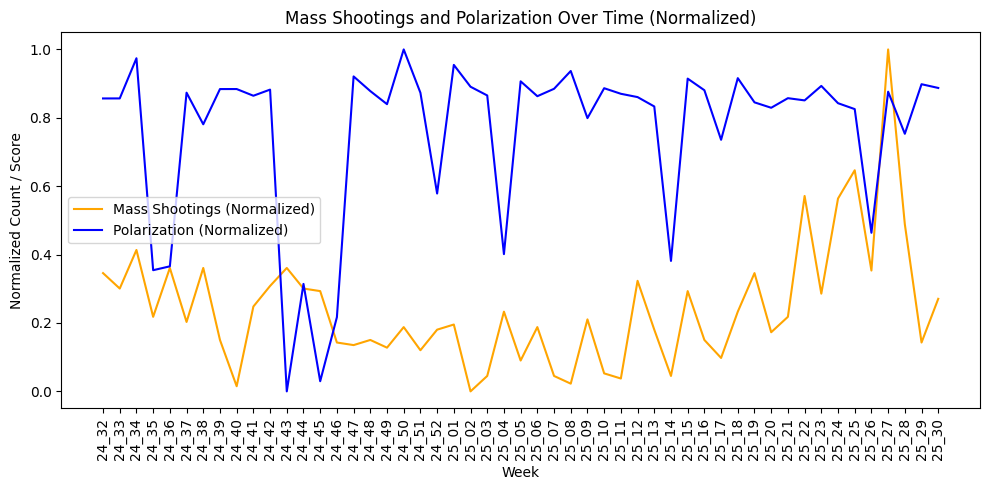

In [64]:
# correlation between mass shootings and polarization, normalizing for visualization
mass_shootings_aligned = mass_shootings.reindex(sorted(week_ids), fill_value=0)
mass_shootings_norm = (mass_shootings_aligned - mass_shootings_aligned.min()) / (mass_shootings_aligned.max() - mass_shootings_aligned.min())
polarization_norm = (fig2c_data['guns'] - fig2c_data['guns'].min()) / (fig2c_data['guns'].max() - fig2c_data['guns'].min())
plt.figure(figsize=(10,5))
plt.plot(sorted(week_ids), mass_shootings_norm, color='orange', label='Mass Shootings (Normalized)')
plt.plot(sorted(week_ids), polarization_norm, color='blue', label='Polarization (Normalized)')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.ylabel('Normalized Count / Score')
plt.title('Mass Shootings and Polarization Over Time (Normalized)')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import pearsonr, spearmanr

# Ensure both are pandas Series and aligned by week
X = pd.Series(mass_shootings['victims'], index=sorted(week_ids))
Y = pd.Series(fig2c_data['guns'], index=sorted(week_ids))

# Pearson correlation (linear)
pearson_corr, pearson_p = pearsonr(X, Y)
print(f"Pearson correlation: r={pearson_corr:.3f}, p={pearson_p:.4f}")

# Spearman correlation (rank/monotonic)
spearman_corr, spearman_p = spearmanr(X, Y)
print(f"Spearman correlation: r={spearman_corr:.3f}, p={spearman_p:.4f}")

Pearson correlation: r=0.022, p=0.8804
Spearman correlation: r=0.188, p=0.1855


✓ Loaded from cache: fig2c_data_magnetic_unsigned


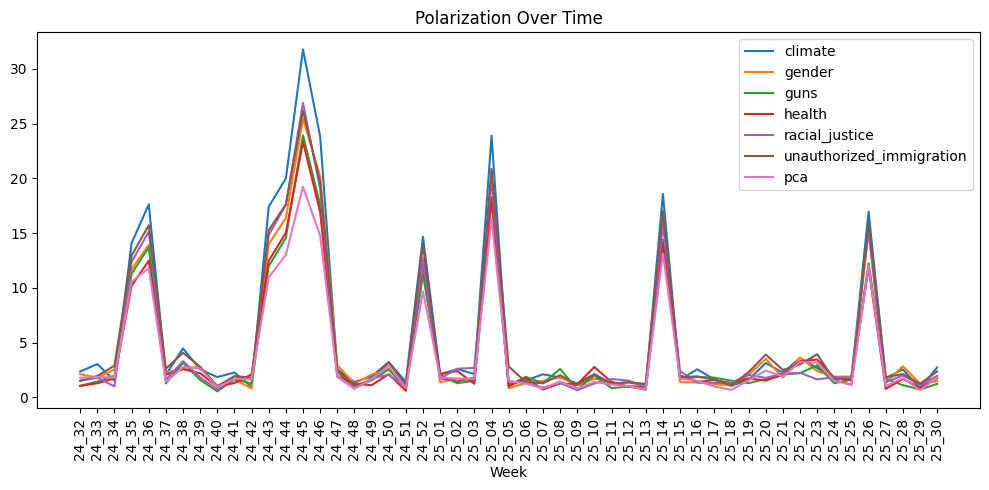

In [44]:
mode = "magnetic"
edge_type = "unsigned"
fig2c_data = load_cache(f'fig2c_data_{mode}_{edge_type}')
fig2c_data.set_index('week', inplace=True)
fig2c_data.shape

plt.figure(figsize=(10,5))
for topic in fig2c_data.columns[1:-2]:
    plt.plot(sorted(week_ids), fig2c_data[topic], label=topic)
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Polarization Over Time')
plt.legend()
plt.tight_layout()
plt.show()

## Original polarization calculations

In [9]:
past_final_networks = dict(nodes=[], edges=[])
for edges_filename in sorted(glob.glob('01_preprocess/final_networks/*_edges.tsv')):
    week_id = edges_filename.split('01_preprocess/final_networks/')[1].split('_edges.tsv')[0]
    
    past_final_networks['edges'].append(pd.read_csv(f'01_preprocess/final_networks/{week_id}_edges.tsv', sep='\t'))
    past_final_networks['nodes'].append(pd.read_csv(f'01_preprocess/final_networks/{week_id}_nodes.tsv', sep='\t'))

In [10]:
past_polarization = pd.read_csv('02_ideological/fig_2c.csv', sep='\t').set_index('week')
past_polarization.head()

,abortion,climate,gender,guns,health,racial_justice,unauthorized_immigration,global,spearman_r,spearman_p
week,,,,,,,,,,
24-32,21.174145,26.495359,21.388475,18.734043,17.470768,21.722589,20.970003,16.292500,0.040398,0.009860
24-33,20.561205,22.950233,20.231165,18.841042,19.314892,21.894136,21.806139,18.310476,0.044728,0.008151
24-34,17.987640,20.372387,18.350685,17.473619,17.306374,19.848886,18.279140,15.222302,-0.003267,0.835423
24-35,16.336514,20.575279,18.435575,16.423346,16.536907,18.376522,18.212345,14.719221,0.033174,0.051781
24-36,19.624708,22.566559,17.817554,17.509827,17.266563,19.340107,20.404066,14.924517,-0.003919,0.808658


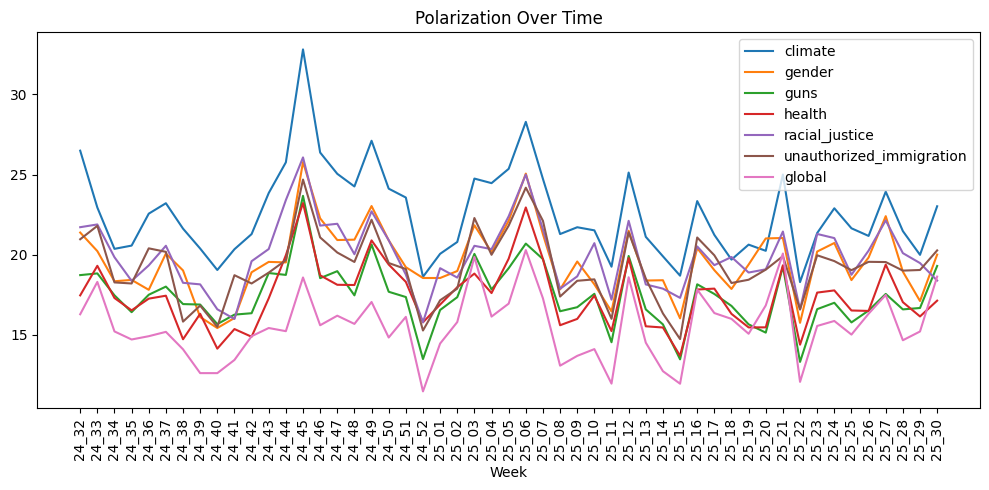

In [11]:
plt.figure(figsize=(10,5))
for topic in past_polarization.columns[1:-2]:
    plt.plot(sorted(week_ids), past_polarization[topic], label=topic)
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Polarization Over Time')
plt.legend()
plt.tight_layout()
plt.show()

## Isolating the node vector

In order to do that, we substract the generated node_vects with a "neutral" node vector, that could be got by:
- node_vector = 1
    I'm not really sure, because node_vector is between -1 and 1. 1 is not neutral
- node_vector with random values

The rationale is: with ge and classical Laplacian, we obtain a value which describe topology, topic and interaction between structure and topic.
With the Magnetic Laplacian, this get lost because as we can see from the plot below:
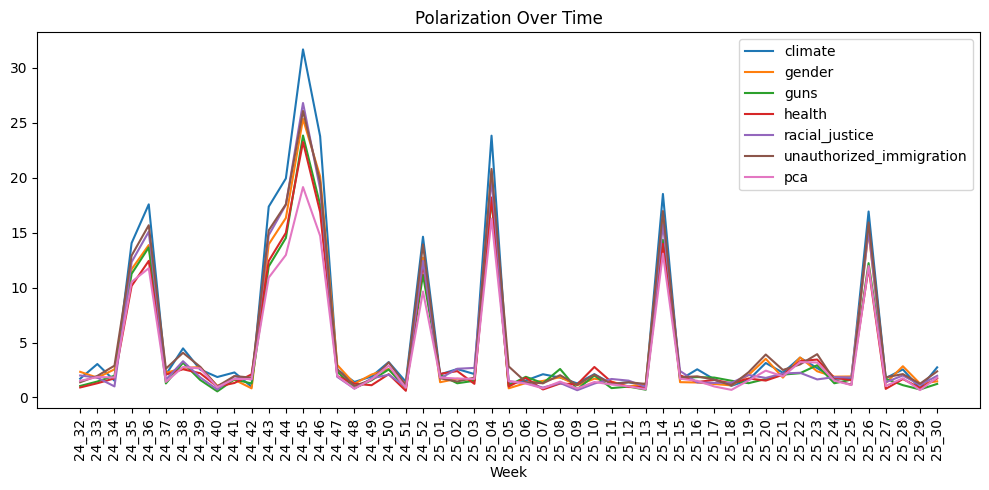

It values the topology, but it forgots the stance.

In [34]:
is_directed = False
mode = "magnetic" if is_directed else "classic"
edge_type = "signed"
final_networks = cache.load_final_networks(is_directed)

Loading 51 final networks...


100%|██████████| 51/51 [00:00<00:00, 876.97it/s]


Calculating polarization scores...


100%|██████████| 51/51 [00:24<00:00,  2.08it/s]


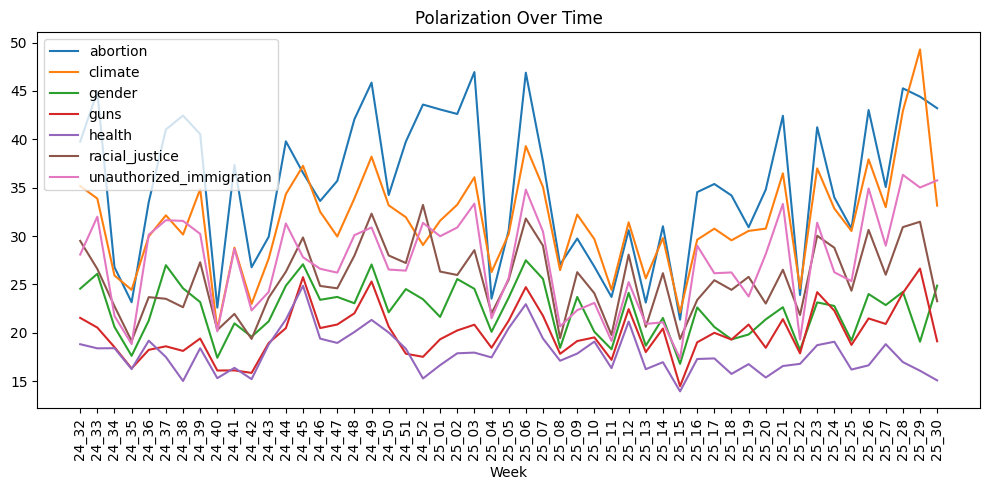

In [36]:
def ge(node_vects, Linv = None):
    return float(torch.sqrt(node_vects.t().matmul(Linv.matmul(node_vects))).cpu().numpy())

def numpy_ge(node_vects, Linv = None):
    return float(np.sqrt(np.matmul(node_vects.transpose(), np.matmul(Linv, node_vects))))

# Figure 2c: Polarization scores (from 02_ideological/07_fig_2c.py)
def calculate_polarization2(networks, mode="magnetic", edge_type="unsigned"):
    """Calculate polarization scores for all weeks using graph Laplacians"""
    results = []
    
    print("Calculating polarization scores...")
    for week in tqdm(week_ids):
        index = week_ids.index(week)
        edges = networks['edges'][index]
        nodes = networks['nodes'][index]
        
        if mode == "classic" and edge_type == "signed":
            edges['weight'] = np.where(edges['toxic'] > toxicity_threshold, -edges['weight'], edges['weight'])
        elif mode == "classic" and edge_type == "unsigned":
            # edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
            pass
        elif mode == "magnetic" and edge_type == "signed":
            edges['weight'] = np.where(edges['toxic'] > toxicity_threshold, -edges['weight'], edges['weight'])
        elif mode == "magnetic" and edge_type == "unsigned":
            edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
        
        # Create PyTorch Geometric tensor
        if is_directed:
            tensor = torch_geometric.data.Data(
                edge_index=torch.tensor(
                    np.array([edges["#src"].values, edges["trg"].values]),
                    dtype=torch.long
                ).to(device),
                node_vects=torch.tensor(
                    nodes.sort_values(by="node").set_index("node").drop("community", axis=1).fillna(0).values,#.drop("community", axis=1).values,
                    dtype=torch.float32
                ).to(device),
                edge_attr=torch.tensor(
                    edges[["weight", "signific", "toxic", "disagreement"]].values,
                    dtype=torch.float32
                ).to(device)
            )
        else:
            tensor = torch_geometric.data.Data(
                edge_index = torch.tensor(
                    np.array([pd.concat([edges["#src"], edges["trg"]]).values, pd.concat([edges["trg"], edges["#src"]]).values]),
                    dtype = torch.long).to(device),
                node_vects = torch.tensor(
                    nodes.sort_values(by = "node").set_index("node").drop("community", axis=1).fillna(0).values,
                    dtype = torch.float32).to(device),
                edge_attr = torch.tensor(
                    pd.concat([edges[["weight", "signific", "toxic", "disagreement"]], edges[["weight", "signific", "toxic", "disagreement"]]]).values,
                    dtype = torch.float32).to(device)
            )
        
        # Calculate pseudoinverse of Laplacian
        Linv = ps._Linv(tensor, mode=mode, edges=edge_type)
        
        # # Calculate polarization (using first topic/PCA component)
        pol = [ge(tensor.node_vects[:, i], Linv) for i in range(tensor.node_vects.shape[1])]
        
        # pol_A = [ge(tensor.node_vects[:, i], Linv) for i in range(tensor.node_vects.shape[1])]
        # neutral_valued_nodes = (2 * torch.rand(1000, tensor.node_vects.shape[0], tensor.node_vects.shape[1]) - 1).mean(dim=0)
        # # neutral_valued_nodes = torch.ones(tensor.node_vects.shape[0])
        # pol_B = [ge(neutral_valued_nodes[:, i], Linv) for i in range(tensor.node_vects.shape[1])]

        # pol = (np.array(pol_A) - np.array(pol_B)).tolist()
        
        # pol = [ge(torch.full([tensor.node_vects.shape[0]], 1).type(dtype=torch.float32), Linv* 100) for i in range(tensor.node_vects.shape[1])]
        
        # pol = [ge(torch.sub(neutral_valued_nodes, tensor.node_vects)[:, i], Linv=Linv) for i in range(tensor.node_vects.shape[1])]
        
        # Calculate Spearman correlation between disagreement and toxicity
        r, p = spearmanr(
            tensor.edge_attr[:,2].cpu().numpy(),
            tensor.edge_attr[:,3].cpu().numpy()
        )
        
        results.append((week, *pol, r, p))
        # results.append((week, *pol_B, r, p))

    polarization = pd.DataFrame(
        data=results,
        columns=("week", *nodes.columns[1:-1], "spearman_r", "spearman_p")
    )
    
    return polarization

# Figure 2c: Polarization scores (from 02_ideological/07_fig_2c.py)
def numpy_calculate_polarization2(networks, mode="magnetic", edge_type="unsigned"):
    """Calculate polarization scores for all weeks using graph Laplacians"""
    results = []
    
    print("Calculating polarization scores...")
    for week in tqdm(week_ids):
        index = week_ids.index(week)
        edges = networks['edges'][index]
        nodes = networks['nodes'][index]
        
        if mode == "classic" and edge_type == "signed":
            edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
        elif mode == "magnetic" and edge_type == "unsigned":
            pass
        elif mode == "magnetic" and edge_type == "signed":
            edges['weight'] = np.where(edges['toxic'] > toxicity_threshold, -edges['weight'], edges['weight'])
        elif mode == "magnetic" and edge_type == "unsigned":
            edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
        
        # Create PyTorch Geometric tensor
        if is_directed:
            tensor = dict(
                edge_index=np.array([edges["#src"].values, edges["trg"].values], dtype=np.longlong),
                node_vects=np.array(nodes.sort_values(by="node").set_index("node").values, dtype=np.float32),
                edge_attr=np.array(edges[["weight", "signific", "toxic", "disagreement"]].values, dtype=np.float32)
            )
        else:
            tensor = torch_geometric.data.Data(
                edge_index = torch.tensor(
                    np.array([pd.concat([edges["#src"], edges["trg"]]).values, pd.concat([edges["trg"], edges["#src"]]).values]),
                    dtype = torch.long).to(device),
                node_vects = torch.tensor(
                    nodes.sort_values(by = "node").set_index("node").drop("community", axis=1).values,
                    dtype = torch.float32).to(device),
                edge_attr = torch.tensor(
                    pd.concat([edges[["weight", "signific", "toxic", "disagreement"]], edges[["weight", "signific", "toxic", "disagreement"]]]).values,
                    dtype = torch.float32).to(device)
            )
        
        # Calculate pseudoinverse of Laplacian
        Linv = ps._numpy_Linv(tensor, mode=mode, edges=edge_type)
        
        # # Calculate polarization (using first topic/PCA component)
        pol = [numpy_ge(tensor['node_vects'][:, i], Linv) for i in range(tensor['node_vects'].shape[1])]
        
        # pol_A = [numpy_ge(tensor.node_vects[:, i], Linv) for i in range(tensor.node_vects.shape[1])]
        # neutral_valued_nodes = (2 * torch.rand(1000, tensor.node_vects.shape[0], tensor.node_vects.shape[1]) - 1).mean(dim=0)
        # # neutral_valued_nodes = torch.ones(tensor.node_vects.shape[0])
        # pol_B = [numpy_ge(neutral_valued_nodes[:, i], Linv) for i in range(tensor.node_vects.shape[1])]

        # pol = (np.array(pol_A) - np.array(pol_B)).tolist()
        
        # pol = [numpy_ge(torch.full([tensor.node_vects.shape[0]], 1).type(dtype=torch.float32), Linv* 100) for i in range(tensor.node_vects.shape[1])]
        
        # pol = [numpy_ge(torch.sub(neutral_valued_nodes, tensor.node_vects)[:, i], Linv=Linv) for i in range(tensor.node_vects.shape[1])]
        
        # Calculate Spearman correlation between disagreement and toxicity
        r, p = spearmanr(
            tensor['edge_attr'][:,2],#.cpu().numpy(),
            tensor['edge_attr'][:,3]#.cpu().numpy()
        )
        
        results.append((week, *pol, r, p))
        # results.append((week, *pol_B, r, p))

    topics = nodes.columns[1:] if is_directed else nodes.columns[1:-1]
    polarization = pd.DataFrame(
        data=results,
        columns=("week", *topics, "spearman_r", "spearman_p")
    )
    
    return polarization

# Calculate polarization
toxicity_threshold = 0.75

# if fig2c_data is None and final_networks is not None:
polarization_data = calculate_polarization2(final_networks, mode=mode, edge_type=edge_type)
# numpy_polarization_data = numpy_calculate_polarization2(fn, mode=mode, edge_type=edge_type)


polarization_data.set_index('week', inplace=True)
# numpy_polarization_data.set_index('week', inplace=True)

plt.figure(figsize=(10,5))
# plt.plot(sorted(week_ids), polarization_data['pca'], label='pytorch')
# plt.plot(sorted(week_ids), numpy_polarization_data['pca'], label='numpy')
for topic in topics:
    plt.plot(sorted(week_ids), polarization_data[topic], label=topic)
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Polarization Over Time')
plt.legend()
plt.tight_layout()
plt.show()

Loading 51 final networks...


100%|██████████| 51/51 [00:00<00:00, 734.25it/s]


Calculating polarization scores...


100%|██████████| 51/51 [00:08<00:00,  6.30it/s]


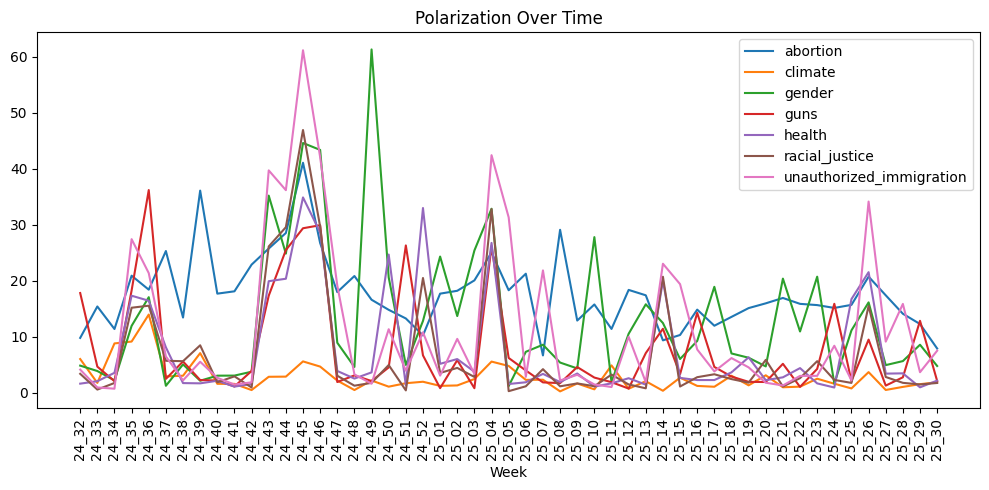

In [45]:
def ge(node_vects, Linv = None):
    return float(torch.sqrt(node_vects.t().matmul(Linv.matmul(node_vects))).cpu().numpy())

# Figure 2c: Polarization scores (from 02_ideological/07_fig_2c.py)
def calculate_polarization2(networks, mode="magnetic", edge_type="unsigned"):
    """Calculate polarization scores for all weeks using graph Laplacians"""
    results = []
    
    print("Calculating polarization scores...")
    for week in tqdm(week_ids):
        index = week_ids.index(week)
        topics_edges = networks['edges'][index]
        topics_nodes = networks['nodes'][index]
        
        weekly_polarization = []
        for index, topic in enumerate(topics):
            edges = topics_edges[index]
            nodes = topics_nodes[index]
        
            if mode == "magnetic" and edge_type == "signed":
                edges['weight'] = np.where(edges['toxic'] > toxicity_threshold, -edges['weight'], edges['weight'])
            elif mode == "magnetic" and edge_type == "unsigned":
                # edges['weight'] = np.maximum(1 - edges['toxic'], 0.0001)
                pass
        
            tensor = torch_geometric.data.Data(
                edge_index=torch.tensor(
                    np.array([edges["#src"].values, edges["trg"].values]),
                    dtype=torch.long
                ).to(device),
                node_vects=torch.tensor(
                    nodes.sort_values(by="node").set_index("node").values,
                    dtype=torch.float32
                ).to(device),
                edge_attr=torch.tensor(
                    edges[["weight", "signific", "toxic", "disagreement"]].values,
                    dtype=torch.float32
                ).to(device)
            )
            
            # Calculate pseudoinverse of Laplacian
            Linv = ps._Linv(tensor, mode=mode, edges=edge_type)
            
            # # Calculate polarization (using first topic/PCA component)
            pol = ge(tensor.node_vects[:, 0], Linv)
            
            weekly_polarization.append(pol)
            
        
        results.append((week, *weekly_polarization))

    polarization = pd.DataFrame(
        data=results,
        columns=("week", *topics)
    )
    
    return polarization

# Calculate polarization
toxicity_threshold = 0.5

multiple_final_networks = cache.load_final_networks(is_directed=True, custom_path='cache/multiple-final_networks')
polarization_data = calculate_polarization2(multiple_final_networks, edge_type="signed")


polarization_data.set_index('week', inplace=True)

plt.figure(figsize=(10,5))
# plt.plot(sorted(week_ids), polarization_data['pca'], label='pytorch')
# plt.plot(sorted(week_ids), numpy_polarization_data['pca'], label='numpy')
for topic in topics:
    plt.plot(sorted(week_ids), polarization_data[topic], label=topic)
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Polarization Over Time')
plt.legend()
plt.tight_layout()
plt.show()

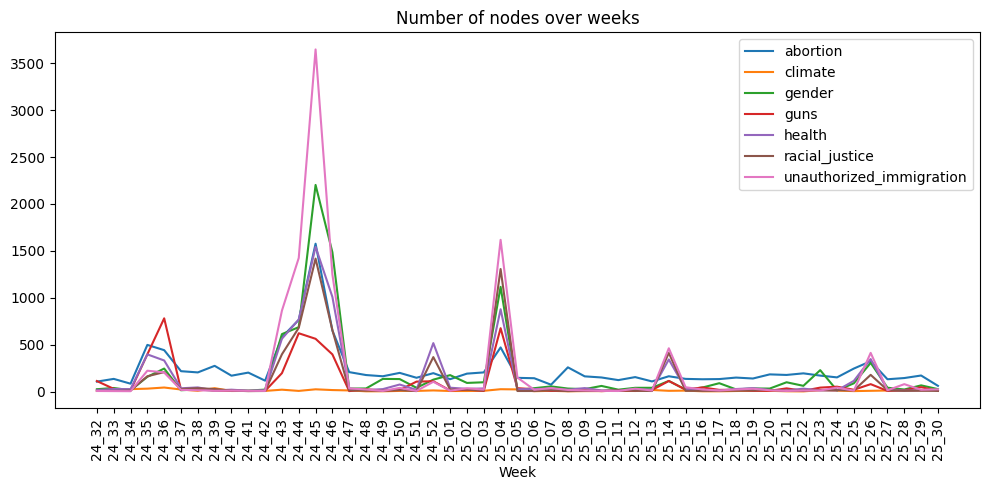

In [39]:
plt.figure(figsize=(10,5))
for index, topic in enumerate(topics):
    plt.plot(sorted(week_ids), [mfn[index].shape[0] for mfn in multiple_final_networks['nodes']], label=topic)
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Number of nodes over weeks')
plt.legend()
plt.tight_layout()
plt.show()

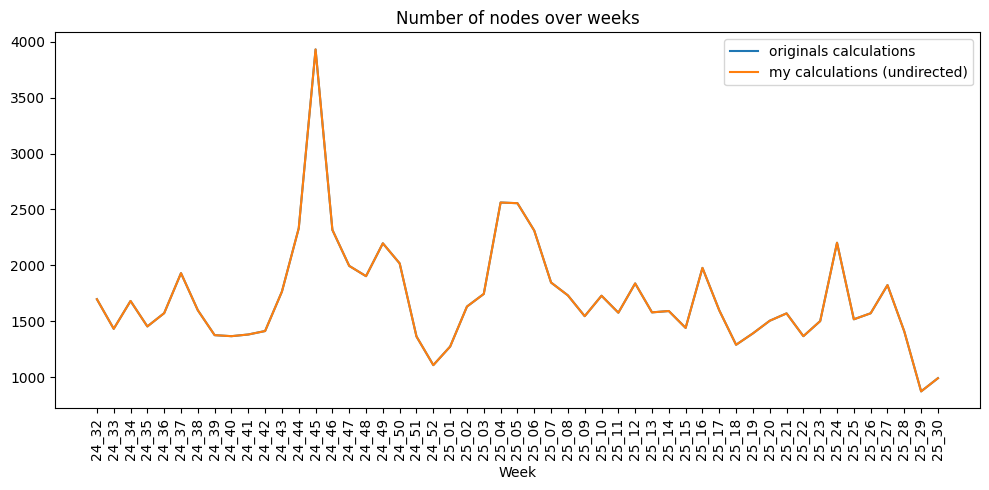

In [14]:
plt.figure(figsize=(10,5))
plt.plot(sorted(week_ids), [wn.shape[0] for wn in past_final_networks['nodes']], label='originals calculations')
plt.plot(sorted(week_ids), [wn.shape[0] for wn in final_networks['nodes']], label=f'my calculations ({"directed" if is_directed else "undirected"})')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Number of nodes over weeks')
plt.legend()
plt.tight_layout()
plt.show()

con il metodo attale ci sono pochi WCC. ho sistemato un pochino andando a prendere la media e adesso ho questi risultati. degli spikes ci sono ugualmente, ma di meno. non sono ancora completamente soddisfatto del risultato, tho. non sono sicuro sia corretto.

ovviamente prendendo la media del resto, è normale che poi il grafico della polarizzazione sia uguale o molto simile tra i topic.

un riscontro interessante è che con le undirected networks, nella settimana '45 ci sono pochissimi nodi (solo 45), ma in realtà è la settimana con più nodi (settimana delle elezioni, polarizzazione massima). (senza prendere la media dei risultati, quindi lasciando il filtro iniziale applicato da Michele)

un "problema" che ho trovato, è che `_select_active_users` ritorna solamente gli utenti che hanno espresso la loro opinione. invece, facendo `userset[userset == 7].index` ritornano solo quelli che hanno scritto almeno 7 messaggi (su qualisiasi topic) (siamo sempre nel caso in cui si sceglie la rolling opinion). quindi, ho aggiunto un return nell'if: `return df, set(userset.index)` [NE DISCUTO CON MICHELE CMQ]
nonostante nella settimana 45 ci siano stati tantissimi messaggi, molti users mandavano solo pochi messaggi. pochissimi hanno mandato tanti messaggi.

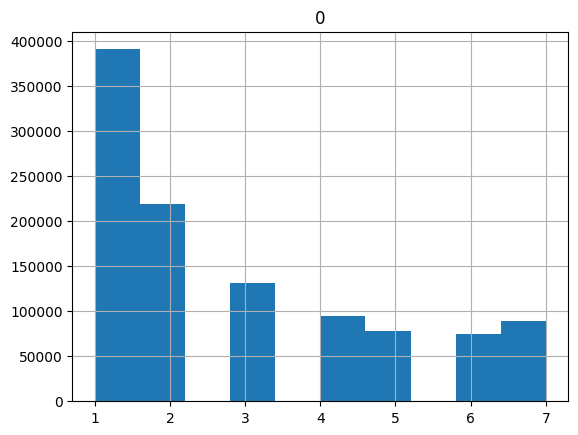
Nella settimana '45 la maggior parte delle persone manda solamente un messaggio.

Sto provando a selezionare solamente gli utenti che hanno mandato almeno 2 messaggi.

Penso di aver capito come mai in alcuni punti la polarizzazione è (quasi) uguale tra tutti i topic. Dato che viene presa la media, in situazioni in cui ci sono tantissimi messaggi ma dove si hanno valori solo per uno/due topic, il restante (la maggior parte) avranno tutti lo stesso valore.

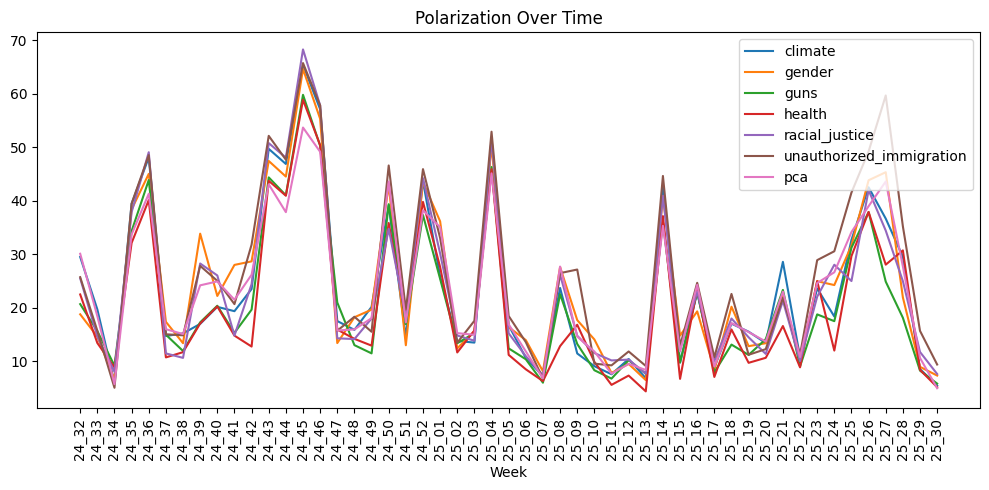 (magnetic e signed)
i picchi sono i momenti in cui si hanno più messaggi singoli, pertanto è più facile trovare una polarizzazione che è molto simile/uguale tra i topic

Non è possibile ignorare i NaN topics. Invece, fillando a 0, ottengo:

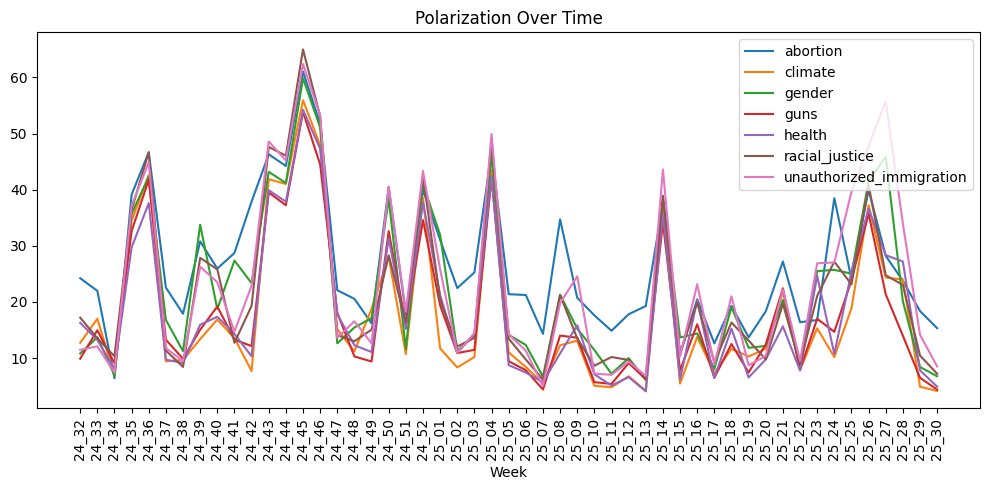 (magnetic signed)


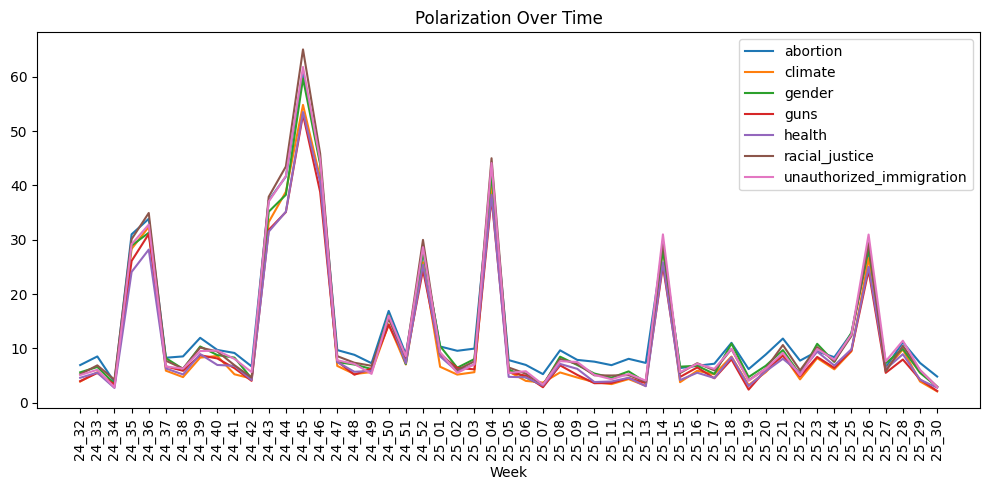 (magnetic UNsigned), ovvero ottenuta pesando gli archi con: `1-toxicity`

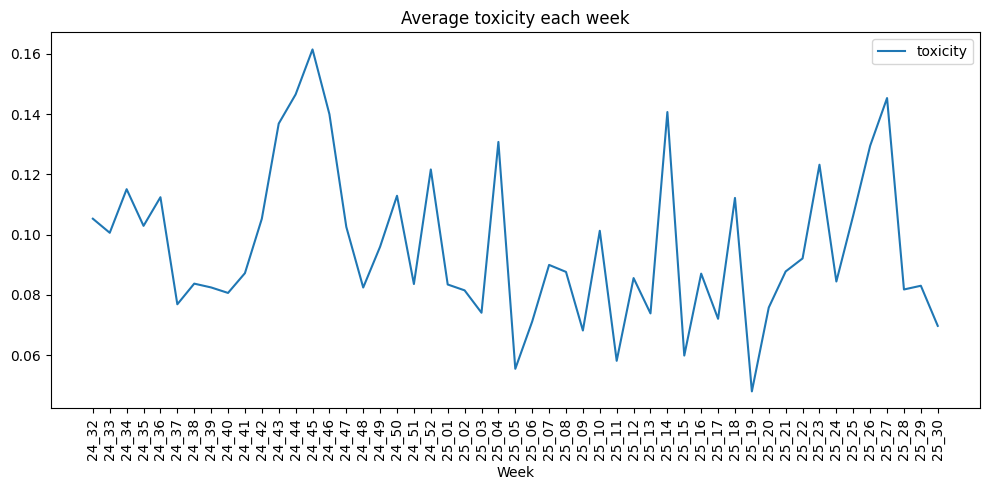

In [18]:
plt.figure(figsize=(10,5))
plt.plot(sorted(week_ids), [fn['toxic'].mean() for fn in final_networks['edges']], label='toxicity')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Average toxicity each week')
plt.legend()
plt.tight_layout()
plt.show()

Undirected graph sembra avere risultati più consistenti.

La questione dei picchi con valori molto simili per topic, quando le settimane sono piene di messaggi, rimane e rimarrà.

- Se si rimuovono gli utenti che hanno solo una o due interazioni per topic, si rischia di avere un picco verso il basso di numero di nodi in settimane molto movimentate (eg: `24_45`)
- Se si calcola la media sui restanti topic su cui l'utente non ha espresso parere, al contrario, nei picchi dove c'è molta attività, la polarizzazione tra topic sarà simile e forse non da una vera e propria misura.

## Social Balance

In [37]:
def get_social_balance(networks, week_ids, toxicity_threshold = 0.5):
    df = []
    for week in tqdm(week_ids):
        index = week_ids.index(week)
        edges = networks['edges'][index]
        nodes = networks['nodes'][index]
        
        nodes = nodes.set_index("node")
        
        edges['sign'] = np.where(edges['toxic'] > toxicity_threshold, -1, 1)

        # We start from the signed adjacncy matrix
        A = pd.pivot_table(data = edges, index = "#src", columns = "trg", values = "sign")
        # We make sure it is squared, since A at the moment is upper triangular we might miss some rows and columns
        A = A.reindex(index = nodes.index, columns = nodes.index).fillna(0)
        # We sum A with its transpose, making it undirected
        A += A.T
        # Put it on the GPU to speed up calculations
        A = torch.from_numpy(A.values).float().to(device).to_sparse()
        # Raising an adjacency matrix to the power of 3 gives for each entry in the diagonal the number of cycles of length 3 (triangles) around the corrseponding node
        # Since it is signed, it is counting the number of balanced triangles minus the unbalanced ones
        A3 = torch.linalg.matrix_power(A, 3)
        # By raising to the power of 3 the unsigned adjacency (taking its absolute value) we count all triangles, whether balanced or not
        A3_abs = torch.linalg.matrix_power(torch.abs(A), 3)
        A3_indices = A3.indices()
        # With this we can select the diagonal
        diagonal = A3_indices[0] == A3_indices[1]
        # By summing all entries in the diagonal we calculate the trace of the matrix
        # The ratio of the trace of signed over unsigned adjacency is how many balanced triangles we have over all triangles in the network
        # The higher the more balanced the network (and therefore the more polarization)
        overall_balance = float(A3.values()[diagonal].sum() / A3_abs.values()[diagonal].sum())
        df.append((week, overall_balance))

    df = pd.DataFrame(data = df, columns = ("week", "overall_balance"))
    return df

fn = cache.load_final_networks(is_directed=False)
sb = get_social_balance(fn, week_ids)
sb

Loading 51 final networks...


100%|██████████| 51/51 [00:01<00:00, 28.87it/s]


,week,overall_balance
0,24_32,0.869565
1,24_33,0.846154
2,24_34,0.521739
3,24_35,0.600000
4,24_36,0.692308
5,24_37,0.719298
6,24_38,0.451613
7,24_39,0.384615
8,24_40,0.854545
9,24_41,0.698113


In [38]:
for topic in topics:
    print(sb.set_index('week')['overall_balance'].corr(polarization_data[topic]))

-0.10133202099651271
-0.13714355587129198
-0.08732484428303834
-0.21776506297634368
-0.3008454025777273
-0.13051468404482602
-0.024441499822362225


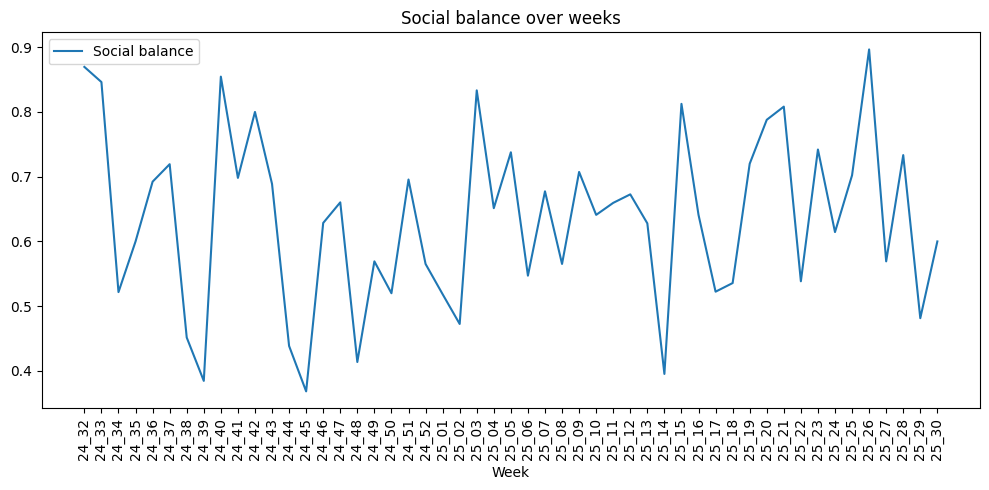

In [39]:
plt.figure(figsize=(10,5))
plt.plot(sorted(week_ids), sb.set_index('week')['overall_balance'], label=f'Social balance')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Social balance over weeks')
plt.legend()
plt.tight_layout()
plt.show()

In [137]:
def get_triangles(networks, week_ids, topic='pca', toxicity_threshold = 0.1):
    df = []
    for week in tqdm(week_ids):
        index = week_ids.index(week)
        edges = networks['edges'][index]
        nodes = networks['nodes'][index]
        
        nodes = nodes.set_index("node")
        
        edges['sign'] = np.where(edges['toxic'] > toxicity_threshold, -1, 1)
        
        G = nx.from_pandas_edgelist(
            edges,
            source="#src",
            target="trg",
        )
        cliques = list(nx.enumerate_all_cliques(G))
        triangles = [clique for clique in cliques if len(clique) == 3]
        
        plusplusplus = 0
        plusminmin = 0

        for triangle in triangles:
            dems = [nodes.iloc[triangle[0]][topic] >= 0, nodes.iloc[triangle[1]][topic] >= 0, nodes.iloc[triangle[2]][topic] >= 0]
            reps = [not d for d in dems]
            interactions = [
                edges[edges["#src"] == triangle[0]][edges["trg"] == triangle[1]]['sign'].values or
                    edges[edges["#src"] == triangle[1]][edges["trg"] == triangle[0]]['sign'].values,
                edges[edges["#src"] == triangle[1]][edges["trg"] == triangle[2]]['sign'].values or 
                    edges[edges["#src"] == triangle[2]][edges["trg"] == triangle[1]]['sign'].values,
                edges[edges["#src"] == triangle[2]][edges["trg"] == triangle[0]]['sign'].values or
                    edges[edges["#src"] == triangle[0]][edges["trg"] == triangle[2]]['sign'].values,
            ]
            interactions = [i.item() for i in interactions]
            # only positive interactions in a group of likely-minded peers
            if (all(dems) and all(i == 1 for i in interactions)) or (all(reps) and all(i == 1 for i in interactions)):
                plusplusplus += 1
            # 2 vs 1: positive interaction between two peers that have negative against another one
            # the index of the two true values in dems is the index of which I want to access to iterations array and check whether the iterations[truedems[0]] and iterations[truedems[1]]
            elif (sum(dems) == 2 and len([1 for i, d in enumerate(dems) if d and interactions[i] == 1]) == 2) or (sum(reps) == 2 and len([1 for i, r in enumerate(reps) if r and interactions[i] == 1]) == 2):
                plusminmin += 1

        df.append((plusplusplus, plusplusplus / len(triangles), plusminmin, plusminmin / len(triangles), len(triangles)))
        
    return pd.DataFrame(data=df, columns=("+++", "+++%", "+--", "+--%", "triangles"), index=week_ids)

In [132]:
sbt = []
for topic in topics:
    sbt.append(get_triangles(fn, week_ids, topic=topic))

100%|██████████| 51/51 [00:06<00:00,  8.22it/s]


In [142]:
fn['nodes'][19]

,node,abortion,climate,gender,guns,health,racial_justice,unauthorized_immigration,pca,community
0,0,-0.250000,-0.727046,0.000000,0.000000,-0.202556,0.783241,0.250000,-0.064097,3
1,1,-0.917303,-0.670565,-0.112026,-0.379429,-0.911980,-1.000000,-0.250000,-0.763255,1
2,2,-0.194325,-0.500000,-0.500000,0.211200,-0.146583,-0.072036,-0.585188,-0.379646,1
3,3,-0.210283,0.462460,-0.500000,-0.098530,0.789981,0.337067,-1.000000,-0.030649,2
4,4,-0.599180,0.218758,0.172504,0.428571,-0.357347,-0.727046,0.348530,-0.047352,1
...,...,...,...,...,...,...,...,...,...,...
1358,1358,-0.110727,0.394119,-0.697059,-0.137298,-0.500000,0.722318,-0.049789,-0.039656,1
1359,1359,-0.332177,0.030605,-0.137974,0.505956,0.454092,0.783869,0.500000,0.332477,1
1360,1360,1.000000,-0.355391,-0.666667,0.321511,-0.250000,-0.039717,0.000000,-0.081880,2
1361,1361,-0.881128,1.000000,0.386852,0.333333,-0.119586,0.333333,-0.412839,0.210800,3


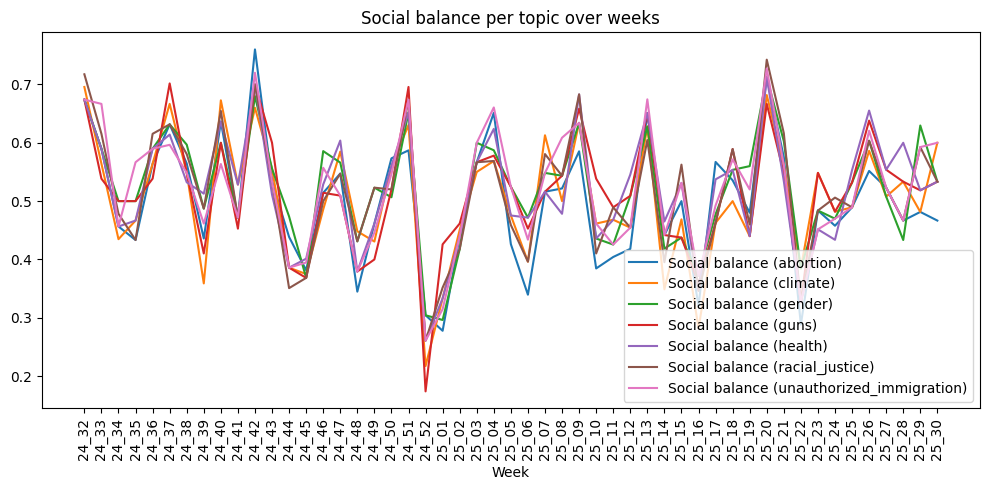

In [134]:
plt.figure(figsize=(10,5))
for i, topic in enumerate(topics):
    plt.plot(sorted(week_ids), sbt[i]['+++%'] + sbt[i]['+--%'], label=f'Social balance ({topic})')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Social balance per topic over weeks')
plt.legend()
plt.tight_layout()
plt.show()

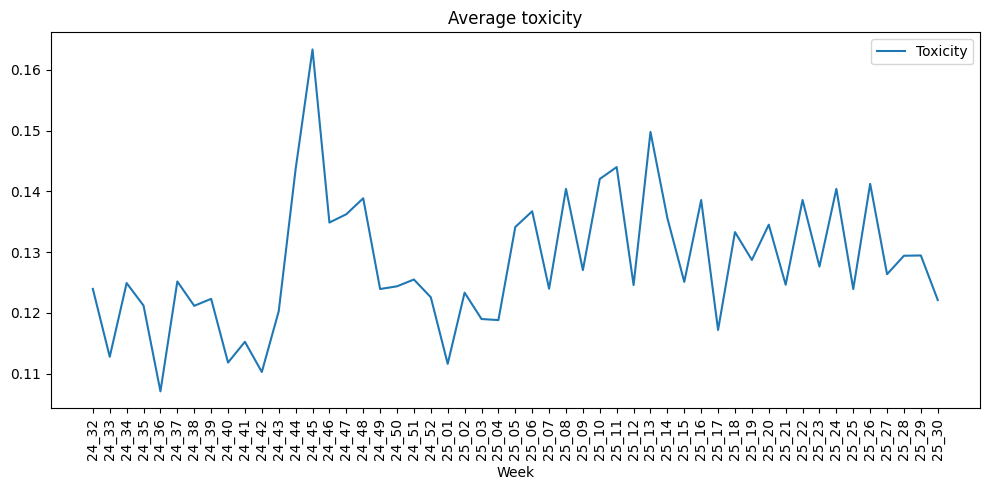

In [99]:
plt.figure(figsize=(10,5))
plt.plot(sorted(week_ids), [weekly_edges['toxic'].mean() for weekly_edges in final_networks['edges']], label=f'Toxicity')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.title('Average toxicity')
plt.legend()
plt.tight_layout()
plt.show()